In [1]:
from ucimlrepo import fetch_ucirepo
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
iris = fetch_ucirepo(id=53) 
X = iris.data.features
y = iris.data.targets['class']

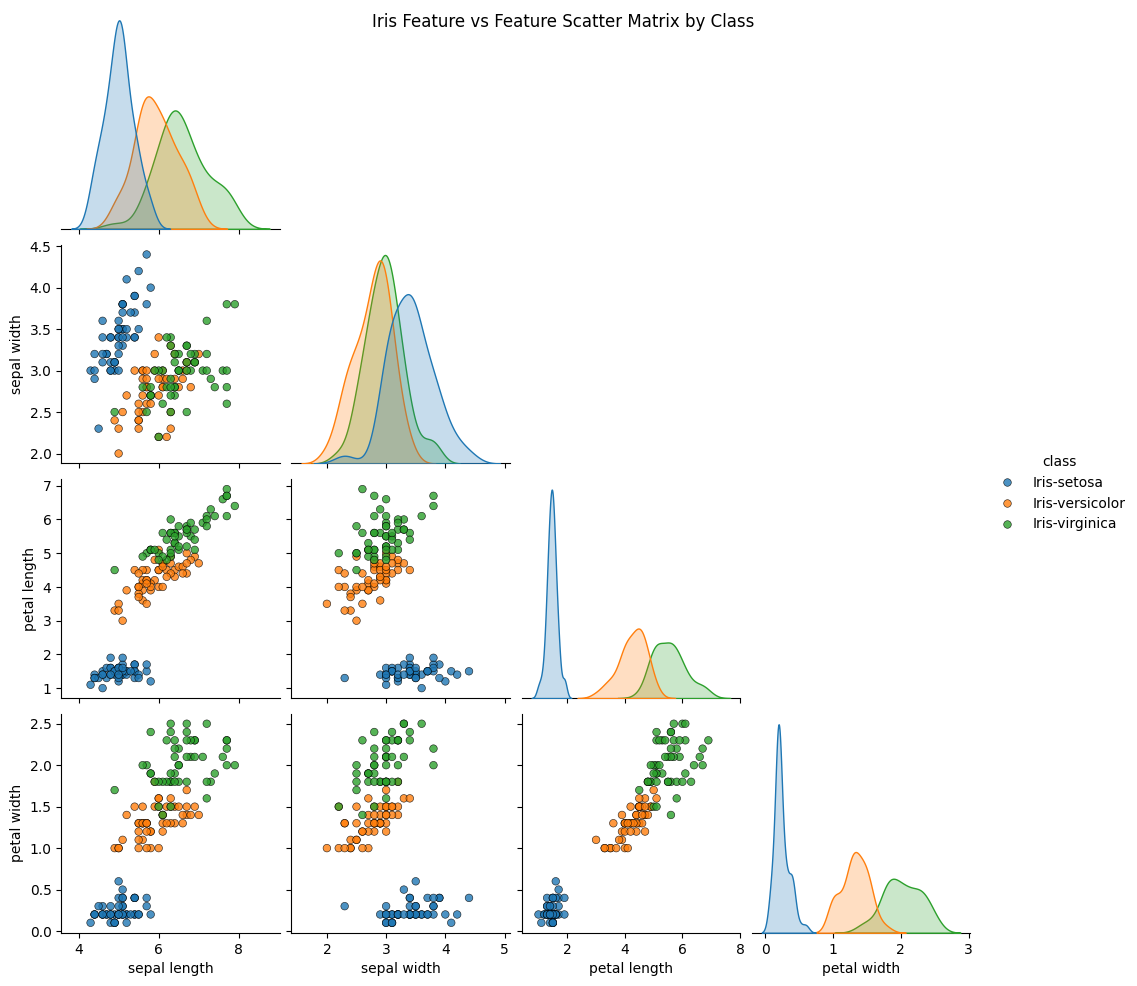

In [3]:
df_plot = X.copy()
df_plot['class'] = y.squeeze()
sns.pairplot(df_plot, hue = 'class', corner = True, plot_kws={'alpha': 0.8, 'edgecolor': 'black', 's': 30})
plt.suptitle('Iris Feature vs Feature Scatter Matrix by Class')
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=7)

In [5]:
knn = KNeighborsClassifier(n_neighbors=3)

In [6]:
pipeline = make_pipeline(knn)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('kneighborsclassifier', KNeighborsClassifier(n_neighbors=3))])

In [7]:
pred = pipeline.predict(X_test)
acc = pipeline.score(X_test, y_test)
print(f"The accuracy of the Nearest Neighbor Classifier is {acc*100}%")

The accuracy of the Nearest Neighbor Classifier is 90.0%


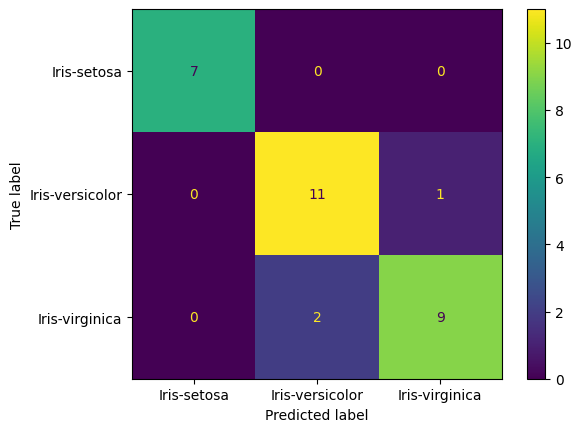

In [8]:
label = y.unique().tolist()
cm = confusion_matrix(y_test, pred)
cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label)
cm_disp.plot();